## Homework 1: Gradient Descent

### Exercise 4: Exact Line Search vs Backtracking


In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
A = np.diag([5.0, 2.0]) 
tolL = .01
toltheta = .01
theta_0 = np.array([3, 3])


def L(theta):
    return 0.5 * (theta.T @ A @ theta)

def grad_L(theta):
    return A @ theta


def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    """
    Return a step size eta that satisfies the Armijo condition:
        L(theta - eta*g) <= L(theta) - c * eta * ||g||^2
    Inputs:
      - L:      R^n -> R
      - grad_L: R^n -> R^d
      - theta:  current point (np.ndarray)
      - eta0:   initial step size
      - beta:   shrinking factor in (0,1)
      - c:      Armijo constant in (0,1)
    """
    eta = eta0
    g = grad_L(theta)
    g_norm2 = np.dot(g, g)
    while L(theta - eta * g) > L(theta) - c * eta * g_norm2:
        eta *= beta
    return eta

def exact_line_search_eta(A, g):
    num = float(g.T @ g)
    den = float(g.T @ A @ g)
    # if den is 0, gradient is 0 -> stationary
    if den == 0:
        return 0.0
    return num / den


def gradient_descent(theta0, eta0, maxit, tolL, toltheta, toggle=True,
       bt_beta=0.5, bt_c=1e-4):
    
    theta = theta0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]
    etas = []

    for it in range(maxit):
        g = grad_L(theta)

        # stopping: small gradient norm
        if np.linalg.norm(g) < tolL:
            break

        if toggle:
            eta = backtracking(L, grad_L, theta, eta0=eta0, beta=bt_beta, c=bt_c)
        else:
            eta = exact_line_search_eta(A, g)

        etas.append(eta)

        theta_next = theta - eta * g

        # stopping: small parameter change
        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L(theta))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L(theta))

    return theta, it, thetas, losses

In [26]:
def quad_levelsets(A, xlim=(-3,3), ylim=(-3,3), ngrid=400, ncontours=12, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)

    Z = 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')

    if title:
        plt.title(title)

    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.grid(alpha=0.2)
    plt.ylim(ylim)
    plt.xlim(xlim)


def show_sets(eta=0.5, toggle=True, maxit=100):
    sol_theta, it, thetas, losses = gradient_descent(theta_0, eta, maxit, tolL, toltheta, toggle)

    # Level sets
    plt.figure()
    quad_levelsets(A, title='Level sets of 0.5 * theta^T A theta')

    c1 = np.array([0.7, 0.7, 1.0])
    c2 = np.array([0.0, 0.0, 0.8])
    colors = [c1 + (c2 - c1) * t for t in np.linspace(0, 1, len(thetas))]

    thetas = np.array(thetas)

    # Trajectory
    plt.plot(thetas[:,0], thetas[:,1], linewidth=0.75, zorder=1)
    plt.scatter(thetas[:,0], thetas[:,1],
                c=colors, s=15, zorder=2, label="successive thetas")

    if it < maxit - 1:
        plt.scatter(sol_theta[0], sol_theta[1],
                    c="red", s=20, zorder=3,
                    label=f"solution at ({round(sol_theta[0],2)}, {round(sol_theta[1],2)})")

    print("Iterations:", it)

    plt.figure()
    plt.plot(losses)
    plt.title("Loss values vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss value")
    plt.show()


#### Gradient Descent with Backtracking

Iterations: 6


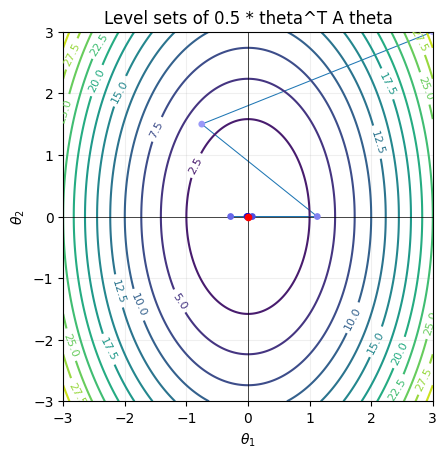

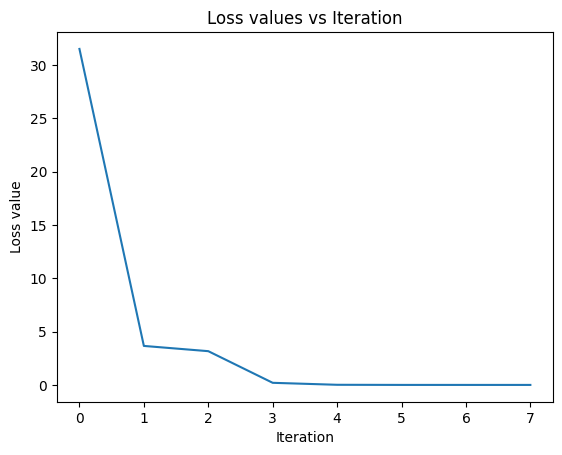

In [27]:
show_sets(toggle = True)

#### Gradient Descent with Exact Line Search

Iterations: 6


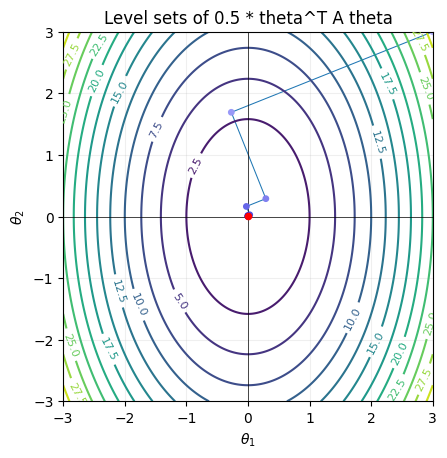

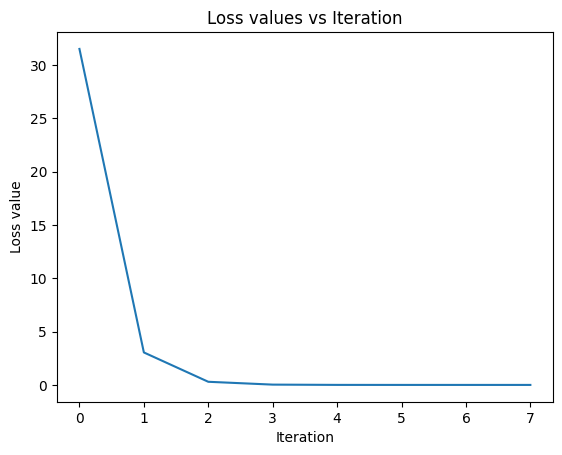

In [28]:
show_sets(toggle = False)